In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


In [2]:
## Full plastic moment
class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    ─────────────────────────────────────────────────────
    Forward : Bisection Method로 인장력 = 압축력 평형점(y_pna) 탐색
    Backward: Implicit Function Theorem(IFT)으로 ∂y_pna/∂coords 계산 후
              chain-rule을 통해 ∂Mp/∂coords 를 GNN까지 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        """
        coords    : [N, 2]  (x, y)
        t         : [N, 1]  두께
        fy        : [N, 1]  항복강도
        edge_index: [2, E]  (사용 안 하지만 인터페이스 유지)
        n_iter    : bisection 반복 횟수
        """
        ## ── 1. Bisection으로 PNA 탐색 (no grad) ──
        with torch.no_grad():
            y = coords[:, 1]                       ## [N]
            t_flat = t.squeeze(-1)                 ## [N]
            fy_flat = fy.squeeze(-1)               ## [N]

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                ## 인장(위쪽) / 압축(아래쪽) 힘
                F_tens = torch.sum(t_flat * fy_flat * torch.clamp(y - y_mid, min=0.0))
                F_comp = torch.sum(t_flat * fy_flat * torch.clamp(y_mid - y, min=0.0))

                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)           ## scalar tensor

        ## ── 2. 전소성 모멘트 Mp = Σ A_i · fy_i · |y_i − y_pna| ──
        d = torch.abs(coords[:, 1] - y_pna)       ## [N]
        area = t_flat                              ## 단위 길이당 면적
        mp_pred = torch.sum(area * fy_flat * d)    ## scalar

        ## backward 에 필요한 텐서 저장
        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        """
        Implicit Function Theorem 적용
        ──────────────────────────────
        평형 조건  g(y_pna, coords) = F_tens − F_comp = 0

        IFT에 의해:
            ∂y_pna/∂y_i = − (∂g/∂y_i) / (∂g/∂y_pna)

        ∂Mp/∂y_i = A_i·fy_i·sign(y_i−y_pna)
                  + Σ_j A_j·fy_j·(−sign(y_j−y_pna)) · (∂y_pna/∂y_i)

        두 번째 항이 IFT 보정 항으로, PNA 이동에 의한 간접 효과를 반영합니다.
        """
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)   ## scalar

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)

        s = torch.sign(y - y_pna)      ## +1(인장), −1(압축)

        ## ── ∂g/∂y_pna  (평형식의 y_pna에 대한 미분) ──
        ##  g = Σ t·fy·clamp(y−y_pna,0) − Σ t·fy·clamp(y_pna−y,0)
        ##  ∂g/∂y_pna = −Σ t·fy · 1[y>y_pna] − Σ t·fy · 1[y<y_pna]
        ##            = −Σ t·fy  (y_pna 정확히 위의 노드 무시)
        dg_dy_pna = -torch.sum(t_flat * fy_flat)   ## scalar (항상 음수)

        ## ── ∂g/∂y_i ──
        ##  i번째 노드가 인장(y_i>y_pna) → ∂g/∂y_i = +t_i·fy_i
        ##  i번째 노드가 압축(y_i<y_pna) → ∂g/∂y_i = −t_i·fy_i  ⟹  = s_i · t_i · fy_i
        dg_dy = s * t_flat * fy_flat               ## [N]

        ## ── IFT: ∂y_pna/∂y_i = −dg_dy / dg_dy_pna ──
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)  ## [N]

        ## ── ∂Mp/∂y_i (직접 항 + IFT 보정 항) ──
        direct = t_flat * fy_flat * s                               ## [N]
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy     ## [N]
        dMp_dy = direct + indirect                                  ## [N]

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None   ## n_iter 추가로 5개


def calculate_mpl(coords, t, fy, edge_index):
    """Wrapper: ImplicitPNASolver.apply 호출"""
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)

In [3]:
## Model Architecture
## : C-GDN (Constraint-aware Graph Deformation Network)
##  - 표준 템플릿(Base Section)을 목표 Mp에 맞춰 **변형**하는 구조
##  - FiLM 레이어로 매 GATv2 블록에 Mp 조건 주입
##  - Hard constraint: 고정점 마스킹

class FiLMGenerator(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM)
    target_mp [B, 1] → (gamma, beta) [B, hidden]
    """
    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )

    def forward(self, target_mp):
        """target_mp: [1, 1] or [B, 1]"""
        out = self.net(target_mp)                       ## [B, 2H]
        gamma, beta = torch.chunk(out, 2, dim=-1)       ## [B, H] each
        return gamma, beta


class CGDNBlock(nn.Module):
    """
    단일 Message-Passing 블록
    GATv2Conv → FiLM modulation → LayerNorm → GELU → Residual
    """
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)

        ## FiLM conditioning: γ ⊙ h + β
        h = gamma * h + beta

        h = self.norm(h)
        h = F.gelu(h)
        h = h + h_res   ## residual
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network

    입력 노드 특징 (R^6):
        [x, y, is_fixed, p_id, t, fy]

    엣지 특징 (R^4):
        [선분 길이, 각도, 레이어 ID, 플랜지 여부]

    조건부 입력:
        target_mp  (목표 전소성 모멘트)
    """

    def __init__(
        self,
        in_channels: int = 6,
        hidden_channels: int = 128,
        num_parts: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,     ## 최대 변위 클리핑 (mm)
    ):
        super().__init__()
        self.max_displacement = max_displacement

        ## 1. Node Encoder ─────────────────────────
        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )

        ## 2. FiLM Generator (Mp 조건 주입) ────────
        self.film_gen = FiLMGenerator(hidden_channels)

        ## 3. GATv2 Message-Passing Blocks ─────────
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_parts)
        ])

        ## 4. Coordinate Decoder ───────────────────
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),               ## 출력: (Δx, Δy)
        )

    def forward(self, x, edge_index, edge_attr, target_mp, is_fixed_mask):
        """
        Parameters
        ----------
        x             : [N, 6]   노드 특징
        edge_index    : [2, E]
        edge_attr     : [E, 4]   엣지 특징
        target_mp     : [1, 1]   목표 전소성 모멘트
        is_fixed_mask : [N, 1]   고정점 Boolean 마스크

        Returns
        -------
        new_coords    : [N, 2]   변형 후 좌표
        delta_coords  : [N, 2]   변위 벡터
        """
        ## ── Encode ──
        h = self.node_encoder(x)

        ## ── FiLM parameters (한 번 생성, 모든 블록에 공유) ──
        gamma, beta = self.film_gen(target_mp)          ## [1, H]

        ## ── Message Passing ──
        for block in self.blocks:
            h = block(h, edge_index, edge_attr, gamma, beta)

        ## ── Decode displacement ──
        delta_coords = self.decoder(h)                  ## [N, 2]

        ## 변위 클리핑 (안정성)
        delta_coords = torch.clamp(delta_coords,
                                   -self.max_displacement,
                                    self.max_displacement)

        ## ── Hard Constraint: 고정점은 변위 = 0 ──
        delta_coords = delta_coords * (~is_fixed_mask).float()

        ## ── 최종 좌표 = Base 좌표 + Δ ──
        new_coords = x[:, :2] + delta_coords

        return new_coords, delta_coords

In [4]:
## Loss Functions

def compute_smoothness_loss(new_coords, edge_index):
    src, dst = edge_index
    diff = new_coords[src] - new_coords[dst]
    return torch.mean(torch.norm(diff, dim=1) ** 2)

def compute_collision_loss(new_coords, part_ids, section_ids, margin=0.5):
    """
    L_collision - 층별(section-wise) 다중 파트 간섭 방지 손실 함수
    Inner(3), Reinf(2), Outer(1) 순서로 Y좌표 간섭을 검사합니다.
    """
    total_collision_loss = torch.tensor(0.0, device=new_coords.device)
    unique_sections = torch.unique(section_ids)
    
    for lvl in unique_sections:
        lvl_mask = (section_ids == lvl)
        y_lvl = new_coords[lvl_mask, 1]
        p_lvl = part_ids[lvl_mask]
        
        mask_1 = (p_lvl == 1) ## Outer
        mask_2 = (p_lvl == 2) ## Reinf
        mask_3 = (p_lvl == 3) ## Inner
        
        ## 1. Inner(3) vs Reinf(2) 간섭 검사 (Reinf가 존재하는 층만 검사)
        if mask_2.any() and mask_3.any():
            ## Inner의 최대 Y가 Reinf의 최소 Y보다 작아야 함 (+ margin)
            gap_3_2 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_2].min() + margin, min=0.0)
            total_collision_loss += gap_3_2 ** 2
            
            ## Reinf(2) vs Outer(1) 간섭 검사
            gap_2_1 = torch.clamp(y_lvl[mask_2].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_2_1 ** 2
            
        ## 2. Reinf(2)가 없는 층 (예: 3층) -> Inner(3) vs Outer(1) 직접 검사
        elif mask_3.any() and mask_1.any():
            gap_3_1 = torch.clamp(y_lvl[mask_3].max() - y_lvl[mask_1].min() + margin, min=0.0)
            total_collision_loss += gap_3_1 ** 2
            
    return total_collision_loss

def compute_mass_loss(new_coords, t, edge_index):
    src, dst = edge_index
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)
    return area

In [5]:
## Training Step
def train_step(model, data, optimizer, target_mps,
               w_phys=1000.0, w_smooth=0.01, w_mass=0.0001,
               w_collision=50.0, w_fix=100.0):
    model.train()
    optimizer.zero_grad()

    x          = data.x                          ## [N, 7]
    edge_index = data.edge_index                 ## [2, E]
    edge_attr  = data.edge_attr                  ## [E, 4]

    ## 특징 인덱스 재정의: [x, y, is_fixed, part_id, section_id, t, fy]
    is_fixed_mask = x[:, 2].bool().unsqueeze(1)  ## [N, 1]
    part_ids      = x[:, 3]                      ## [N]
    section_ids   = x[:, 4]                      ## [N]
    t             = x[:, 5].unsqueeze(1)         ## [N, 1]
    fy            = x[:, 6].unsqueeze(1)         ## [N, 1]

    unique_sections = torch.unique(section_ids)

    ## ── 1. 노드별 목표 Mp 텐서 생성 (FiLM 주입용) ──
    ## 전체 그래프 스칼라 주입이 아닌, 각 노드가 자신이 속한 층의 목표 Mp를 인식하도록 구성합니다.
    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    ## ── 2. GNN Forward Pass ──
    ## FiLM (Feature-wise Linear Modulation) 제너레이터가 [N, 1] 텐서를 받아 
    ## PyTorch의 브로드캐스팅(Broadcasting)을 통해 각 노드별로 고유한 γ, β를 적용합니다.
    new_coords, delta_coords = model(x, edge_index, edge_attr, target_mp_node, is_fixed_mask)

    ## ── 3. 층별 슬라이싱 및 2D 물리 연산 (Slicing & Physics) ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []
    
    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]
        
        ## 개별 층의 전소성 모멘트 계산 (Implicit PNA Solver)
        ## edge_index는 PNA(Plastic Neutral Axis) 평형 탐색 연산에 쓰이지 않으므로 분할 불필요
        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, None)

        ## 해당 층의 고유 목표 Mp 스칼라
        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        ## 해당 층의 목표 대비 오차 누적
        l_phys_section = ((pred_mp_section - target_mp_section) / target_mp_section) ** 2
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())
        
    ## 오차 및 예측된 Mp의 층별 평균 산출
    num_sections = len(unique_sections)
    l_phys_total = l_phys_total / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 3. 다목적 손실 함수 계산 ──
    l_smooth = compute_smoothness_loss(new_coords, edge_index)
    l_mass = compute_mass_loss(new_coords, t, edge_index)
    l_collision = compute_collision_loss(new_coords, part_ids, section_ids)
    fixed_nodes = is_fixed_mask.squeeze()
    if fixed_nodes.any():
        l_fix = torch.sum(torch.norm(delta_coords[fixed_nodes], dim=1))
    else:
        l_fix = torch.tensor(0.0, device=x.device)

    ## ── Total Loss ──
    loss = (w_phys * l_phys_total
          + w_smooth * l_smooth
          + w_mass * l_mass
          + w_collision * l_collision
          + w_fix * l_fix)

    loss.backward()
    optimizer.step()

    return {
        "loss":        loss.item(),
        "pred_mp":     pred_mp_sections,
        "l_phys":      l_phys_total.item(),
        "l_smooth":    l_smooth.item(),
        "l_mass":      l_mass.item(),
        "l_collision": l_collision.item(),
        "l_fix":       l_fix.item() if isinstance(l_fix, torch.Tensor) else l_fix,
        "new_coords":  new_coords.detach(),
    }

Nodes: torch.Size([80, 7]) | Edges: torch.Size([2, 272]) | Edge Features: torch.Size([272, 4])


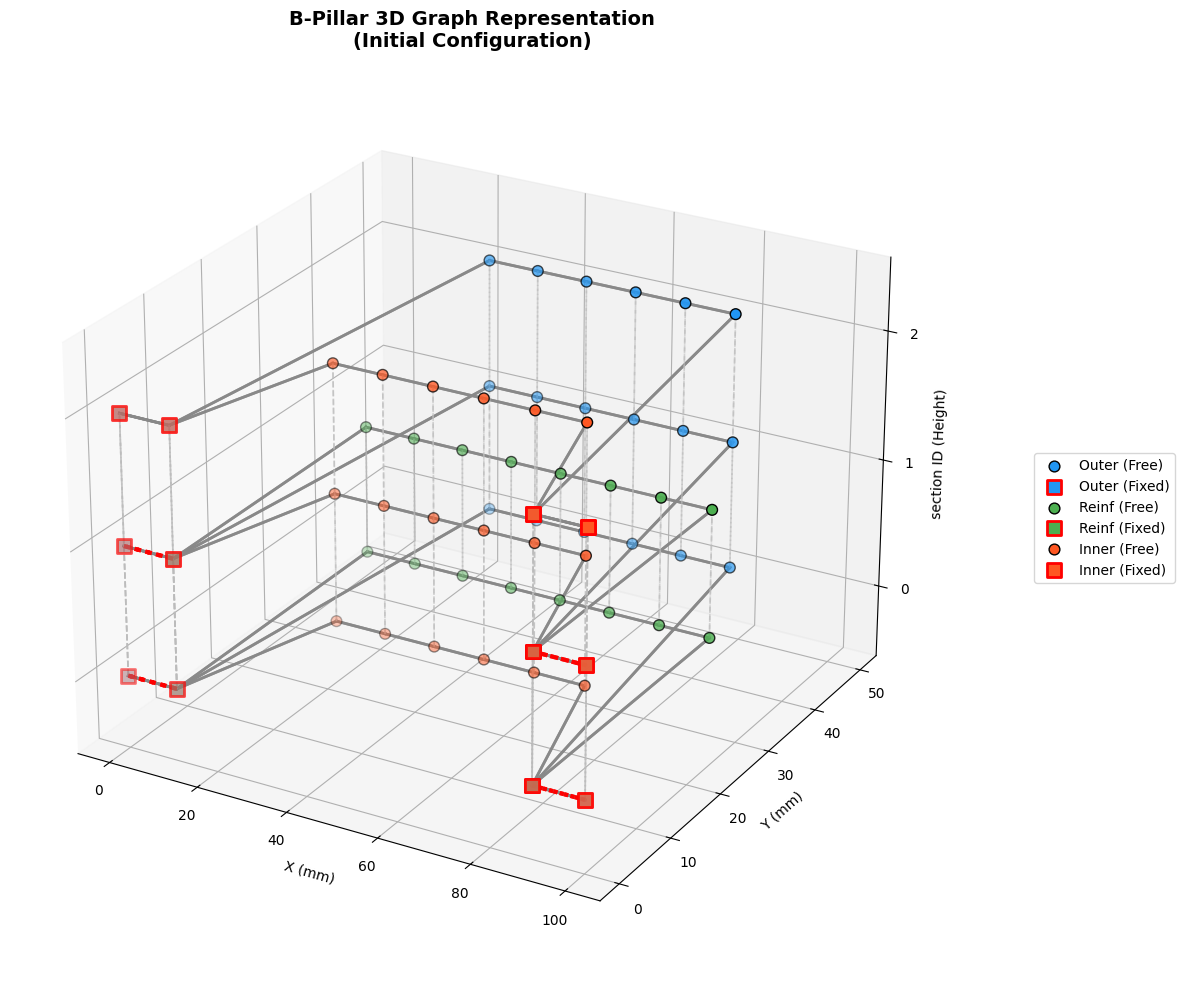

In [6]:
## data
"""
section 3개
  - section 2 (3층): part 0, 2
  - section 1 (2층): part 0, 1, 2
  - section 0 (1층): part 0, 1, 2

part 3개
  - part 0 (b): 노드 0, 1, 8, 9 fixed, 나머지 y=50
  - part 1 (g): 노드 0, 1, 8, 9 fixed, 나머지 y=35
  - part 2 (r): 노드 0, 1, 8, 9 fixed, 나머지 y=20

x: [N, 7]  (x, y, is_fixed, part_id, section_id, t, fy)
  - part_id: 0=Outer, 1=Reinf, 2=Inner
  - t = [1.5, 2.0, 1.5]
  - fy = [1500, 1500, 1200]

edge_index: [2, E] (양방향 연결)

edge_attr: [E, 4] (length, angle, part_id, edge_type)
  - edge_type: 0=part 내 엣지, 1=section 간 엣지, 2=fixed 노드 간 엣지


"""

# ── 1. 노드 구성 설계 ──
# 파트별 노드 수: 10
num_nodes_total = 80
num_nodes = 10
# [x, y, is_fixed, part_id, section_id, t, fy]
x = torch.zeros((num_nodes_total, 7), dtype=torch.float32)

node_registry = {}  ## (section, part, i) -> node_index 매핑용 딕셔너리
current_idx = 0

# 노드 생성 루프
for section in [0, 1, 2]:
    parts_in_section = [0, 1, 2] if section in [0, 1] else [0, 2] ## 3층은 파트 1 제외
    
    for part in parts_in_section:        
        for i in range(num_nodes):
            ## ── 기하학적 초기 좌표 (x, y) 할당 ──
            if part == 1:
                ## 파트 1(Reinf): 양 끝점은 파트 0의 i=1, i=8과 동일한 좌표
                if i == 0:
                    ## 파트 0의 i=1 좌표를 사용
                    x_coord = 1 * (100.0 / 9.0)
                    y_coord = 0.0
                elif i == 9:
                    ## 파트 0의 i=8 좌표를 사용
                    x_coord = 8 * (100.0 / 9.0)
                    y_coord = 0.0
                else:
                    ## 중간 노드들: 균등 분할
                    # x_coord = i * (7 * (100.0 / 9.0) / 9.0) + (100.0 / 9.0)  ## i=1 ~ i=8 사이 균등 분할
                    x_coord = i * (100.0 / 9.0)  ## i=1 ~ i=8 사이 균등 분할
                    y_coord = 35.0  ## Reinf
            else:
                ## 파트 0, 2: x좌표 0 ~ 100mm 로 균등 분할
                x_coord = i * (100.0 / 9.0)
                
                ## y좌표: x축(y=0) 기준 거리. 파트 2(Inner)가 가장 가깝고, 파트 0(Outer)이 가장 멉니다.
                ## 양 끝점(i=0, i=9)은 파트 0, 2가 플랜지에서 만나도록 y=0으로 설정
                if i in [0, 1, 8, 9]:
                    y_coord = 0.0
                else:
                    if part == 2: y_coord = 20.0       ## Inner
                    elif part == 0: y_coord = 50.0     ## Outer
                
            ## ── 고정점 (is_fixed) 마스킹 ──
            ## 파트 0(Outer)과 파트 2(Inner)의 양 끝점 + 파트 1(Reinf)의 양 끝점(i=0, i=9)은 고정
            is_fixed = 1.0 if ((part in [0, 2] and (i in [0, 1, 8, 9])) or 
                               (part == 1 and (i in [0, 9]))) else 0.0
            
            ## 물성치 (단순 가정)
            t = 1.5 if part != 1 else 2.0  ## 보강재(파트 1)는 두께 2.0mm
            fy = 1500.0 if part != 2 else 1200.0 ## 파트별 강도 차등
            
            x[current_idx] = torch.tensor(
                [x_coord, y_coord, is_fixed, part, section, t, fy]
            )
            node_registry[(section, part, i)] = current_idx
            current_idx += 1

# ── 2. 엣지 (edge_index) 및 특성 (edge_attr) 구성 ──
src_list, dst_list = [], []
edge_attr_list = [] ## [length, angle, part_id, edge_type (0=part, 1=section, 2=fixed)]

def add_edge(u, v, part_id, edge_type):
    """양방향 엣지를 추가하고 특성을 계산하는 헬퍼 함수"""
    src_list.extend([u, v])
    dst_list.extend([v, u])
    
    ## 기하학적 특성 계산 (길이, 각도)
    dx = x[v, 0] - x[u, 0]
    dy = x[v, 1] - x[u, 1]
    length = math.sqrt(dx**2 + dy**2)
    angle = math.atan2(dy, dx)
    
    ## 양방향 동일 특성 부여
    edge_attr_list.extend([[length, angle, part_id, edge_type], 
                            [length, -angle, part_id, edge_type]])

# 2-1. 횡방향 엣지 (Intra-section): 같은 층, 같은 파트 내 연속된 노드 연결
for section in [0, 1, 2]:
    parts = [0, 1, 2] if section in [0, 1] else [0, 2]
    for part in parts:
        for i in range(num_nodes - 1):
            u = node_registry[(section, part, i)]
            v = node_registry[(section, part, i+1)]
            add_edge(u, v, part_id=part, edge_type=0.0)
            
# 2-2. 종방향 엣지 (Inter-section): 층간 동일 파트, 동일 인덱스 연결 (3D 연속성 확보)
for section in [0, 1]:
    next_section = section + 1
    ## Section 2(다음 층)에는 파트 1(Reinf)이 없으므로, next_section==2일 때만 파트 1 제외
    parts = [0, 2] if next_section == 2 else [0, 1, 2]
    
    for part in parts:
        for i in range(num_nodes):
            u = node_registry[(section, part, i)]
            v = node_registry[(next_section, part, i)]
            add_edge(u, v, part_id=part, edge_type=1.0)

# 2-3. 플랜지 접합 (Flange Bind): 파트 끝점 묶기
for section in [0, 1, 2]:
    for i in [0, 9]:
            u0 = node_registry[(section, 0, i)] # Outer
            u2 = node_registry[(section, 2, i)] # Inner
            
            # 1섹션, 2섹션의 경우 0-1, 1-2, 0-2 모두 강건하게 묶어줌
            if section in [0, 1]:
                u1 = node_registry[(section, 1, i)] # Reinf
                add_edge(u0, u1, part_id=0.0, edge_type=2.0)
                add_edge(u1, u2, part_id=0.0, edge_type=2.0)
                
            # 0-2 파트는 모든 섹션에서 공통으로 결합
            add_edge(u0, u2, part_id=0.0, edge_type=2.0)


# 텐서 변환
edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32)

x, edge_index, edge_attr
print(f"Nodes: {x.shape} | Edges: {edge_index.shape} | Edge Features: {edge_attr.shape}")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x_np = x.cpu().numpy()
ei_np = edge_index.cpu().numpy()
ea_np = edge_attr.cpu().numpy()

color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'} ## Outer, Reinf, Inner

for i in range(ei_np.shape[1]):
    u = ei_np[0, i]
    v = ei_np[1, i]
    e_type = ea_np[i, 3]
    
    xs = [x_np[u, 0], x_np[v, 0]]
    ys = [x_np[u, 1], x_np[v, 1]]
    zs = [x_np[u, 4], x_np[v, 4]]
    
    if e_type == 0.0:
        ax.plot(xs, ys, zs, color='#888888', linestyle='-', linewidth=2.0, alpha=0.9)
    elif e_type == 1.0:
        ax.plot(xs, ys, zs, color='#BBBBBB', linestyle='--', linewidth=1.2, alpha=0.6)
    elif e_type == 2.0:
        ax.plot(xs, ys, zs, color='red', linestyle=':', linewidth=3.0, alpha=0.9)

for part_id in [0, 1, 2]:
    mask = (x_np[:, 3] == part_id) & (x_np[:, 2] == 0.0)
    part_name = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}[part_id]
    ax.scatter(x_np[mask, 0], x_np[mask, 1], x_np[mask, 4], c=color_map[part_id], marker='o', s=60, edgecolors='k', label=f'{part_name} (Free)')
    
    mask_fixed = (x_np[:, 3] == part_id) & (x_np[:, 2] == 1.0)
    if mask_fixed.any():
        ax.scatter(x_np[mask_fixed, 0], x_np[mask_fixed, 1], x_np[mask_fixed, 4], c=color_map[part_id], marker='s', s=100, edgecolors='red', linewidths=2.0, label=f'{part_name} (Fixed)')

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('section ID (Height)')
ax.set_title('B-Pillar 3D Graph Representation\n(Initial Configuration)', fontsize=14, fontweight='bold')

ax.set_zticks([0, 1, 2])
ax.set_zlim(-0.5, 2.5)

# Fix viewing angle for better perspective
ax.view_init(elev=25, azim=-60)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()
plt.show()


In [7]:
print(f"Initial mp \n"
      f"3rd section: {calculate_mpl(x[56:,:2], x[56:,5], x[56:,6], None)}\n"
      f"2nd section: {calculate_mpl(x[28:56,:2], x[28:56,5], x[28:56,6], None)}\n"
      f"1st section: {calculate_mpl(x[:28,:2], x[:28,5], x[:28,6], None)}")

Initial mp 
3rd section: 804905.75
2nd section: 1170134.5
1st section: 1089417.0


C-GDN Training Log
Epoch 000 | Loss: 78.5347 | Mp: [1198655.75  1198646.     758653.125] / [900000.0, 900000.0, 700000.0] | L_phys: 0.0757  L_smooth: 235.9890  L_mass: 4251.9663  L_collision: 0.0000  L_fix: 0.0000
Epoch 010 | Loss: 6.0726 | Mp: [966540.0625 966951.125  680543.1875] / [900000.0, 900000.0, 700000.0] | L_phys: 0.0039  L_smooth: 175.5241  L_mass: 3931.8638  L_collision: 0.0000  L_fix: 0.0000
Epoch 020 | Loss: 4.4207 | Mp: [867471.875 868085.5   651193.5  ] / [900000.0, 900000.0, 700000.0] | L_phys: 0.0025  L_smooth: 156.3069  L_mass: 3826.3159  L_collision: 0.0000  L_fix: 0.0000
Epoch 030 | Loss: 3.0786 | Mp: [919019.375  918968.625  666993.5625] / [900000.0, 900000.0, 700000.0] | L_phys: 0.0010  L_smooth: 165.3074  L_mass: 3874.8013  L_collision: 0.0000  L_fix: 0.0000
Epoch 040 | Loss: 3.0799 | Mp: [897105.5   896960.625 660051.   ] / [900000.0, 900000.0, 700000.0] | L_phys: 0.0011  L_smooth: 160.2703  L_mass: 3842.3694  L_collision: 0.0000  L_fix: 0.0000
Epoch 050 | Loss

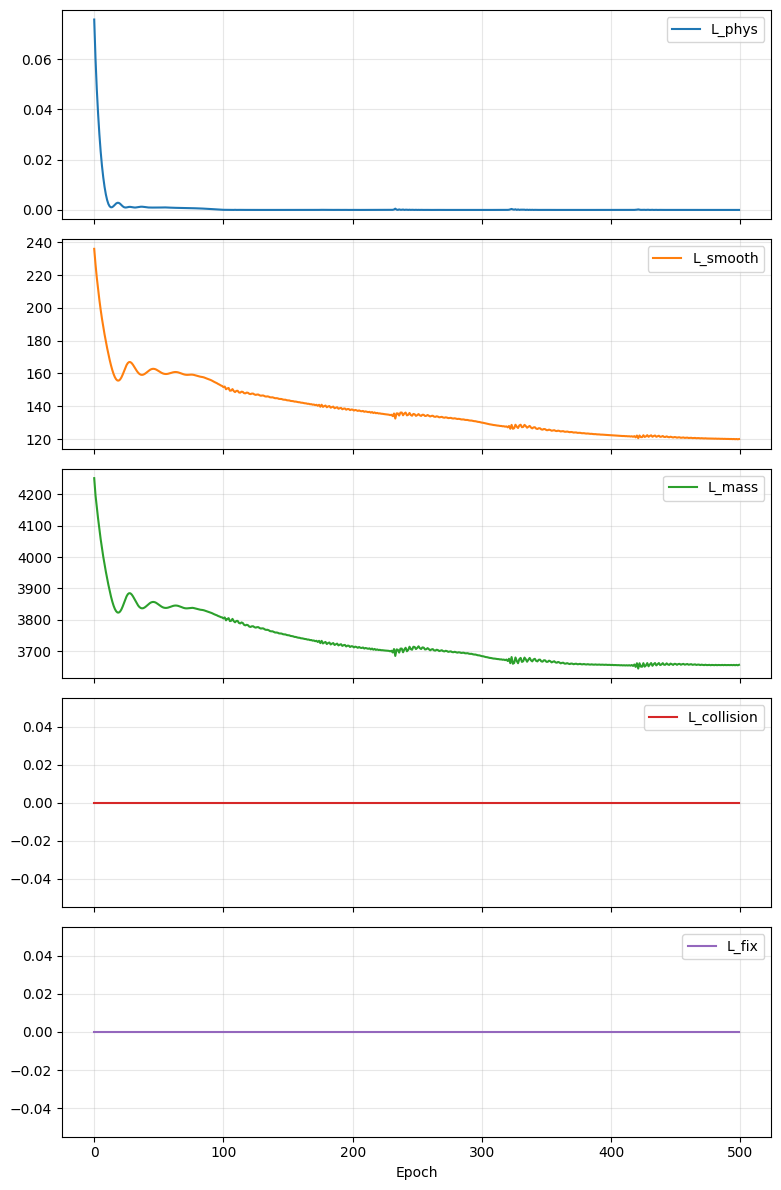

In [8]:
## run
if __name__ == "__main__":

    ## ── Hyperparameters & Setup ──
    in_channels = 7
    hidden_channels = 128
    num_parts = 4
    heads = 4
    edge_feature_dim = 4
    learning_rate = 1e-3
    weight_decay = 1e-4
    max_epochs = 500
    target_mps = [900000, 900000, 700000]
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ## ── 모델 초기화 ──
    model = CGDN(
        in_channels=in_channels, hidden_channels=hidden_channels,
        num_parts=num_parts, heads=heads, edge_dim=edge_feature_dim,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr).to(device)

    ## ── Training Loop ──
    print("=" * 60)
    print("C-GDN Training Log")
    print("=" * 60)

    ## loss history 저장
    loss_hist = []
    l_phys_hist = []
    l_smooth_hist = []
    l_mass_hist = []
    l_collision_hist = []
    l_fix_hist = []

    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps)

        ## 서브로스들 기록
        l_phys_hist.append(info['l_phys'])
        l_smooth_hist.append(info['l_smooth'])
        l_mass_hist.append(info['l_mass'])
        l_collision_hist.append(info['l_collision'])
        l_fix_hist.append(info['l_fix'])
        loss_hist.append(info['loss'])

        if epoch % 10 == 0:
            target_mp_str = ', '.join(f'{mp:.1f}' for mp in target_mps)
            print(
                f"Epoch {epoch:03d} | "
                f"Loss: {info['loss']:.4f} | "
                f"Mp: {info['pred_mp']} / [{target_mp_str}] | "
                f"L_phys: {info['l_phys']:.4f}  "
                f"L_smooth: {info['l_smooth']:.4f}  "
                f"L_mass: {info['l_mass']:.4f}  "
                f"L_collision: {info['l_collision']:.4f}  "
                f"L_fix: {info['l_fix']:.4f}"
            )

    ## ── 서브로스 시각화 (5x1 subplot) ──
    epochs = list(range(max_epochs))
    fig, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True)
    axes[0].plot(epochs, l_phys_hist, label='L_phys', color='C0')
    axes[1].plot(epochs, l_smooth_hist, label='L_smooth', color='C1')
    axes[2].plot(epochs, l_mass_hist, label='L_mass', color='C2')
    axes[3].plot(epochs, l_collision_hist, label='L_collision', color='C3')
    axes[4].plot(epochs, l_fix_hist, label='L_fix', color='C4')
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
    axes[-1].set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()


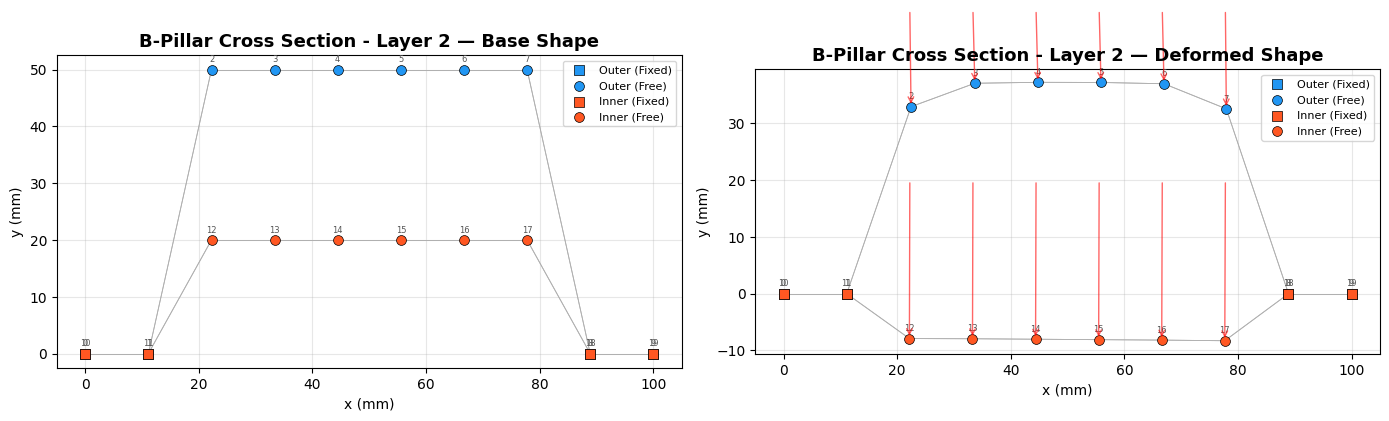

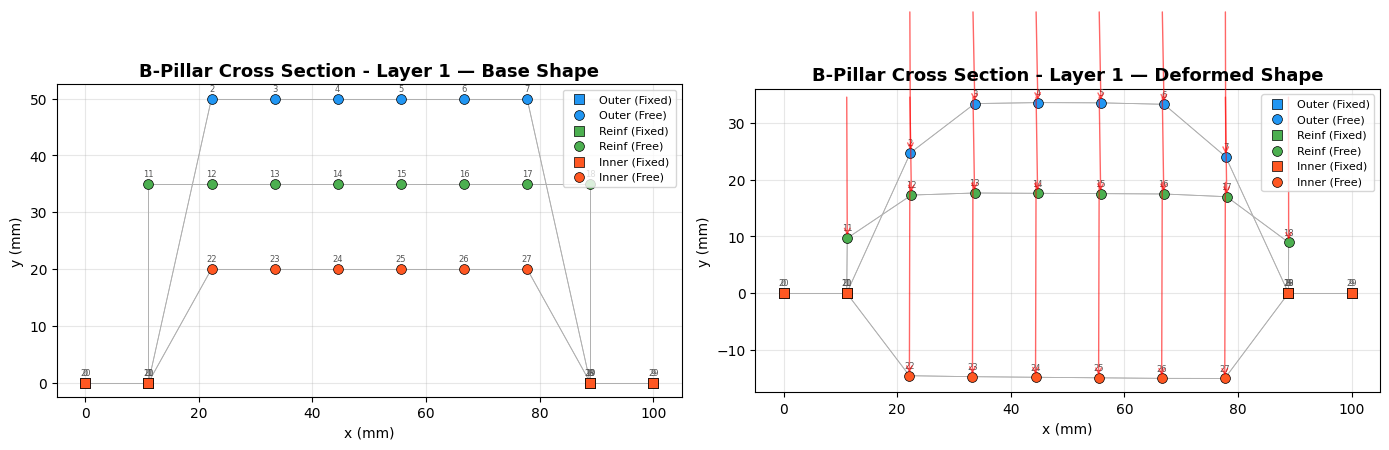

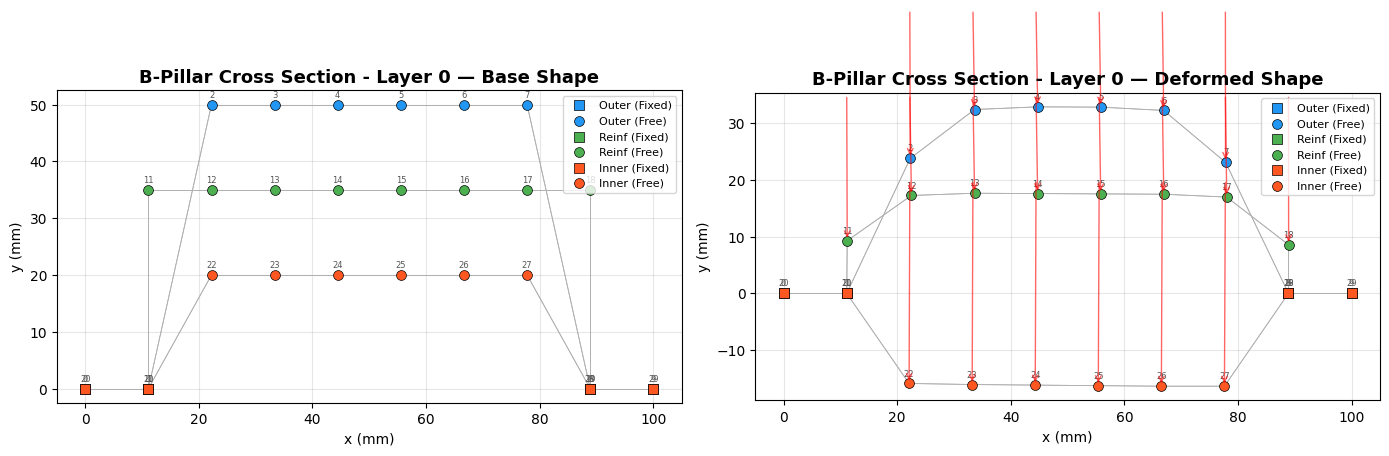

In [9]:
##  B-Pillar 단면 형상 시각화 (노드 & 엣지)

def visualize_section(coords, edge_index, x_features, title="B-Pillar Cross Section",
                      deformed_coords=None, figsize=(14, 7), section_start=0):
    """
    Parameters
    ----------
    coords         : [N, 2]  노드 좌표 (x, y)
    edge_index     : [2, E]  엣지 인덱스 (글로벌)
    x_features     : [N, 6]  노드 특징 [x, y, is_fixed, part_id, t, fy]
    deformed_coords: [N, 2]  변형 후 좌표 (선택)
    section_start  : 이 섹션의 글로벌 시작 인덱스
    """
    section_end = section_start + coords.shape[0]
    
    ## 이 섹션에만 포함된 엣지 필터링 및 인덱스 재매핑
    mask = (edge_index[0] >= section_start) & (edge_index[0] < section_end) & \
           (edge_index[1] >= section_start) & (edge_index[1] < section_end)
    local_edge_index = edge_index[:, mask] - section_start
    
    is_fixed  = x_features[:, 2].cpu().numpy().astype(bool)
    part_ids = x_features[:, 3].cpu().numpy().astype(int)
    coords_np = coords.cpu().detach().numpy()
    ei = local_edge_index.cpu().numpy()

    n_plots = 2 if deformed_coords is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]

    def _draw(ax, pts, subtitle):
        ## ── 엣지 그리기 ──
        for i in range(ei.shape[1]):
            s, d = ei[0, i], ei[1, i]
            ax.plot([pts[s, 0], pts[d, 0]],
                    [pts[s, 1], pts[d, 1]],
                    color='#b0b0b0', linewidth=0.6, zorder=1)

        ## ── 노드 그리기 (전체 파트: 0=Outer, 1=Reinf, 2=Inner) ──
        colors_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}   ## Outer=파랑, Reinf=초록, Inner=주황
        marker_map = {True: 's', False: 'o'}         ## 고정=사각, 자유=원
        label_map  = {True: 'Fixed', False: 'Free'}
        part_name = {0: 'Outer', 1: 'Reinf', 2: 'Inner'}

        for lid in [0, 1, 2]:
            for fix in [True, False]:
                mask = (part_ids == lid) & (is_fixed == fix)
                if not mask.any():
                    continue
                lbl = f'{part_name[lid]} ({label_map[fix]})'
                ax.scatter(pts[mask, 0], pts[mask, 1],
                           c=colors_map[lid],
                           marker=marker_map[fix],
                           s=50, edgecolors='k', linewidths=0.5,
                           zorder=3, label=lbl)

        ## ── 노드 인덱스 표시 ──
        for i in range(len(pts)):
            ax.annotate(str(i), (pts[i, 0], pts[i, 1]),
                        fontsize=6, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points',
                        color='#555555')

        ax.set_title(subtitle, fontsize=13, fontweight='bold')
        ax.set_xlabel('x (mm)')
        ax.set_ylabel('y (mm)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    ## ── 원본(Base) 형상 ──
    _draw(axes[0], coords_np, f'{title} — Base Shape')

    ## ── 변형(Deformed) 형상 ──
    if deformed_coords is not None:
        def_np = deformed_coords.cpu().detach().numpy()
        _draw(axes[1], def_np, f'{title} — Deformed Shape')

        ## 변위 화살표 오버레이
        for i in range(len(coords_np)):
            dx = def_np[i, 0] - coords_np[i, 0]
            dy = def_np[i, 1] - coords_np[i, 1]
            if np.sqrt(dx**2 + dy**2) > 1e-4:
                axes[1].annotate('',
                    xy=(def_np[i, 0], def_np[i, 1]),
                    xytext=(coords_np[i, 0], coords_np[i, 1]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.0, alpha=0.6))

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════════
#  시각화 실행
# ═══════════════════════════════════════════════════════════
num_nodes_in_section = [30, 30, 20]  ## 섹션별 노드 수
section_offsets = [0]
for n in num_nodes_in_section[:-1]:
    section_offsets.append(section_offsets[-1] + n)

for i in (2, 1, 0):
    s, e = section_offsets[i], section_offsets[i] + num_nodes_in_section[i]
    base_coords = data.x[s:e, :2]              ## 초기 좌표
    deformed    = info['new_coords'][s:e]      ## 학습 후 변형 좌표
    section_features = data.x[s:e, :]

    visualize_section(
        coords=base_coords,
        edge_index=data.edge_index,
        x_features=section_features,
        title=f'B-Pillar Cross Section - Layer {i}',
        deformed_coords=deformed,
        section_start=s,
    )